## Proximal Policy Optimization in the Foraging Environment

Runtime: ~ 2 mins

While standard **Proximal Policy Optimization (PPO)** typically updates after collecting multiple independent episodes, our "Foraging" environment operates as a **reset-free, single-episode** task. To bridge this gap, we implement a **sliding collection window** approach that maintains the on-policy requirement without requiring environment resets.

#### 1. Sequential Data Collection

Instead of full episodes, we define a **Collection Interval** ($C$) of **512 time steps**.

* The agent interacts with the environment starting from its current state, $s_t$.
* It follows the current policy $\pi_\theta$ for $C$ steps, generating a single continuous trajectory segment: $\tau = \{s_t, a_t, r_t, \dots, s_{t+C}\}$.

#### 2. Synchronization Point ($s_{pause}$)

At the end of the interval, the environment is "paused" at state $s_{pause}$. This state serves two purposes:

* **Update Trigger:** It marks the end of the data buffer needed for the PPO update.
* **Next-Step Anchor:** It acts as the initial state for the subsequent collection cycle, ensuring temporal continuity in the agent's life-cycle.

#### 3. On-Policy Update

Using the buffer of 512 transitions, we perform the PPO update (calculating advantages, clipping the surrogate objective, and updating the value function). Because this data was generated by the *immediate* predecessor of the new policy, the **on-policy constraint** is satisfied.

#### 4. Continuous Progression

Once the networks are updated, the agent resumes interaction exactly from $s_{pause}$ using the newly optimized policy $\pi_{\theta'}$. This creates a seamless loop of **Collect $\rightarrow$ Update $\rightarrow$ Resume**, allowing the agent to learn and adapt while navigating the environment indefinitely.


**Note**: Since we are pausing mid-trajectory, when we calculate the advantage (using GAE), we use the Value Network to **bootstrap** the reward from the final state ($s_{pause}$). Otherwise, the agent will mistakenly learn that the world ends every 512 steps.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed

### PPO Learner

In [ ]:
# -------------------------
# Time-embedding
# -------------------------
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super(TimeEmbedding, self).__init__()
        self.freqs = (2 * np.pi) / (torch.arange(2, dim + 1, 2))
        self.freqs = self.freqs.unsqueeze(0)

    def forward(self, t):
        t = t.unsqueeze(-1)
        freqs = self.freqs.to(t.device)
        sin = torch.sin(freqs * t)
        cos = torch.cos(freqs * t)

        return torch.cat([sin, cos], dim=-1)
    
# -------------------------
# Rollout Buffer (On-Policy)
# -------------------------
class RolloutBuffer:
    def __init__(self):
        self.states = []
        self.actions = []
        self.times = []
        self.rewards = []
        self.log_probs = []
        self.values = []

    def push(self, state, action, time, reward, log_prob, value):
        self.states.append(state)
        self.actions.append(action)
        self.times.append(time)
        self.rewards.append(reward)
        self.log_probs.append(log_prob)
        self.values.append(value)

    def clear(self):
        self.states.clear()
        self.actions.clear()
        self.times.clear()
        self.rewards.clear()
        self.log_probs.clear()
        self.values.clear()

# -------------------------
# Critic Network (Value Function)
# -------------------------
class ValueNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=128, t_dim=50, include_time=False):
        super(ValueNetwork, self).__init__()
        input_dim = state_dim + t_dim if include_time else state_dim
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, 1)
        self.include_time = include_time
        self.time_embed = TimeEmbedding(t_dim)
        self.state_dim = state_dim

    def forward(self, state, time):
        state = F.one_hot(state, num_classes=self.state_dim).float()
        if self.include_time:
            x = torch.cat([state, self.time_embed(time)], dim=-1)
        else:
            x = state
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc_out(x)
    
# -------------------------
# Actor Network (Policy)
# -------------------------
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128, t_dim=50, include_time=False):
        super(PolicyNetwork, self).__init__()
        input_dim = state_dim + t_dim if include_time else state_dim
        
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, action_dim)
        
        self.include_time = include_time
        self.time_embed = TimeEmbedding(t_dim)
        self.state_dim = state_dim

    def forward(self, state, time):
        state_one_hot = F.one_hot(state, num_classes=self.state_dim).float()
        
        if self.include_time:
            t_emb = self.time_embed(time)
            x = torch.cat([state_one_hot, t_emb], dim=-1)
        else:
            x = state_one_hot
            
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        logits = self.fc_out(x)
        probs = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        return probs, log_probs

    def get_action_dist(self, state, time):
        """
        Helper for the update phase to get a Categorical distribution
        object directly for entropy and log_prob calculations.
        """
        probs, _ = self.forward(state, time)
        return torch.distributions.Categorical(probs)

# -------------------------
# PPO Learner
# -------------------------
class PPOLearner:
    def __init__(self, include_time=False, state_dim=7, action_dim=3, 
                 gamma=0.99, lam=0.95, eps_clip=0.2, K_epochs=10, lr=3e-4):
        # GAE parameters
        self.gamma = gamma
        self.lam = lam 

        self.eps_clip = eps_clip
        self.K_epochs = K_epochs
        self.lr = lr

        self.state_dim = state_dim
        self.action_dim = action_dim
        self.include_time = include_time

        self.policy = PolicyNetwork(state_dim, action_dim, include_time=include_time)
        self.critic = ValueNetwork(state_dim, include_time=include_time)
        
        self.optimizer = optim.Adam([
            {'params': self.policy.parameters(), 'lr': lr},
            {'params': self.critic.parameters(), 'lr': lr}
        ])

        self.buffer = RolloutBuffer()

    def select_action(self, state, time, eval_mode=False):
        with torch.no_grad():
            state_t = torch.LongTensor([state])
            time_t = torch.FloatTensor([time])
            probs, log_probs_all = self.policy(state_t, time_t)
            value = self.critic(state_t, time_t)

            if eval_mode:
                action = torch.argmax(probs, dim=-1).item()
                return action
            else:
                # Sample action
                dist = torch.distributions.Categorical(probs)
                action = dist.sample()
                log_prob = log_probs_all[0, action.item()]
                return action.item(), log_prob.item(), value.item()
            
    def run_current_policy(self, env, state, time, horizon):
        curr_state = state
        curr_time = time
        trajectory = [curr_state]
        rewards = [env._get_current_reward(curr_state, curr_time)]
        for _ in range(horizon):
            action = self.select_action(curr_state, curr_time, eval_mode=True)
            curr_state = env.get_next_state(state=curr_state, action=action)
            curr_time += 1
            trajectory.append(curr_state)
            rewards.append(env._get_current_reward(curr_state, curr_time))
        return trajectory, rewards

    def update(self, next_state, next_time):
        # 1. Prepare data from buffer
        states = torch.LongTensor(self.buffer.states)
        actions = torch.LongTensor(self.buffer.actions)
        times = torch.FloatTensor(self.buffer.times)
        old_log_probs = torch.FloatTensor(self.buffer.log_probs)
        values = torch.FloatTensor(self.buffer.values)
        rewards = self.buffer.rewards

        # 2. Compute GAE and Returns
        with torch.no_grad():
            # Bootstrap
            next_value = self.critic(torch.LongTensor([next_state]), torch.FloatTensor([next_time])).item()
            
            advantages = []
            gae = 0
            for i in reversed(range(len(rewards))):
                # Delta is the temporal difference error
                delta = rewards[i] + self.gamma * next_value - values[i]
                gae = delta + self.gamma * self.lam * gae
                advantages.insert(0, gae)
                next_value = values[i]
            
            advantages = torch.FloatTensor(advantages)
            returns = advantages + values # rewards-to-go
            # Normalize advantages for stability
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # 3. Optimization Loop (K Epochs)
        for _ in range(self.K_epochs):
            # Get current policy distribution and values
            probs, log_probs_all = self.policy(states, times)
            curr_values = self.critic(states, times).squeeze()
            
            curr_log_probs = log_probs_all.gather(1, actions.unsqueeze(1)).squeeze()

            # Compute the entropy bonus (encourage the policy to explore more by maximizing entropy)
            dist = torch.distributions.Categorical(probs)
            entropy = dist.entropy().mean()

            # PPO Ratio calculation
            ratio = torch.exp(curr_log_probs - old_log_probs)

            # Clipped Surrogate Objective
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1 - self.eps_clip, 1 + self.eps_clip) * advantages
            
            # Loss composition: Policy Loss - Entropy Bonus + Value Loss
            policy_loss = -torch.min(surr1, surr2).mean()
            value_loss = F.mse_loss(curr_values, returns)
            
            loss = policy_loss + 0.5 * value_loss - 0.01 * entropy

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

        self.buffer.clear()

### Foraging Environment

In [3]:
class ForagingEnv:
    def __init__(
        self,
        initial_reward: int = 10,
        decay_rate: float = 0.6,
        window_size: int = 10,
        session_length: int = 500000
    ):
        self.initial_reward = initial_reward
        self.decay_rate = decay_rate
        self.window_size = window_size
        self.period = 2 * window_size
        self.session_length = session_length

        self.patch_A = 1
        self.patch_B = 5

        self.rewards_in_session = self._compute_session_rewards()

        self.action_space = [-1, 0, 1]  # left, stay, right
        self.reset()
    
    def reset(self):
        self.current_step = 0
        self.state = 1  # Start at state 1
        return self.state
    
    def get_next_state(self, action, state=None):
        action = self.action_space[action]  # map action index to actual action
        state = self.state if not state else state 
        next_state = state + action
        if state == 0 and next_state < 0:
            next_state = 0
        if state == 6 and next_state > 6:
            next_state = 6
        return next_state
    
    def step(self, action):
        # Action: -1 (left), 0 (stay), +1 (right)
        reward = self._get_current_reward(self.state, self.current_step)
        next_state = self.get_next_state(action)
        self.state = next_state
        self.current_step += 1
        return next_state, reward
    
    def get_state(self):
        return self.state

    def get_time(self):
        return self.current_step
    
    def run_optimal_policy(self, state, time, horizon):
        curr_time = time
        curr_state = state
        trajectory = [curr_state]
        rewards = [self._get_current_reward(curr_state, curr_time)]
        if horizon: 
            for _ in range(horizon):
                target = self._get_current_target(curr_time)
                if curr_state > target:
                    curr_state -= 1
                elif curr_state < target:
                    curr_state += 1
                curr_time += 1
                trajectory.append(curr_state)
                rewards.append(self._get_current_reward(curr_state, curr_time))
        return trajectory, rewards
    
    def _compute_session_rewards(self):
        rewards_per_window = self.initial_reward * self.decay_rate ** np.arange(self.window_size)
        rewards_per_window = rewards_per_window.tolist()
        num_windows, remainder = divmod(self.session_length, self.window_size)
        return rewards_per_window * num_windows + rewards_per_window[:remainder] 

    def _get_current_reward(self, state, time):
        phase = time % self.period
        if state == self.patch_A and phase < self.window_size:
            return self.rewards_in_session[time]
        elif state == self.patch_B and phase >= self.window_size:
            return self.rewards_in_session[time]
        else:
            return 0.0
        
    def _get_current_target(self, time):
        phase = time % self.period
        q1 = self.period // 4
        q3 = self.period // 4 * 3
        if phase <= q1: 
            return self.patch_A
        elif phase > q3:
            return self.patch_A
        else:
            return self.patch_B

### Evaluation

In [7]:
def get_normalized_future_rewards(rewards, gamma):
    Y = np.zeros_like(rewards, dtype=float)
    H = len(rewards)
    
    # Pre-calculate powers of gamma up to the maximum possible horizon
    gammas = gamma ** np.arange(H)

    for t in range(H - 1):
        # The number of steps remaining after time t
        L = H - 1 - t
        
        # Slice the rewards and weights
        future_rewards = rewards[t+1:]
        weights = gammas[:L]
        
        # Normalize and compute the weighted sum
        Y[t] = np.dot(weights, future_rewards) / weights.sum()

    return Y

def evaluate(learner, env, state, time, eval_period=100, gamma=0.5):
    _, pred_rewards = learner.run_current_policy(env, state, time, eval_period)
    _, optimal_rewards = env.run_optimal_policy(state, time, eval_period)

    pred_prewards = get_normalized_future_rewards(pred_rewards[1:], gamma)
    optimal_prewards = get_normalized_future_rewards(optimal_rewards[1:], gamma)
    pregret = np.mean(optimal_prewards - pred_prewards)
    return pregret

### Experiment

In [2]:
import sys
sys.path.append("../")

from src.ppo import PPOLearner
from src.env import ForagingEnv
from src.eval import evaluate

In [3]:
def run_replicate(
    include_time=False,
    update_interval=512,
    eval_period=100,
    terminal_time=100000,
    stochastic=False
):
    env = ForagingEnv(stochastic=stochastic)
    learner = PPOLearner(include_time=include_time)

    t_list = []
    pregret_list = []

    progress_bar = tqdm(range(0, terminal_time))
    for t in progress_bar:
        # get current state
        state = env.get_state()

        # evaluate
        if (t + 1) % eval_period == 0:
            pregret = evaluate(learner, env, state, t)
            pregret_list.append(pregret)
            # print(f"Time {t+1}, Pregret: {pregret:.3f}")
            t_list.append(t+1)

        # --- collect data from the current policy ---

        # Select action
        action, log_prob, value = learner.select_action(state, t)

        # Step in environment
        next_state, reward = env.step(action)

        # Store transition
        learner.buffer.push(state, action, t, reward, log_prob, value)

        # --- update the learner --- 
        if (t + 1) % update_interval == 0:
            learner.update(next_state, t + 1)

    pregret_list = np.array(pregret_list)
    t_list = np.array(t_list)
    return pregret_list, t_list

### Run the Experiment

In [6]:
num_reps = 10
results = {}

# deterministic
output = Parallel(n_jobs=10)(delayed(run_replicate)(include_time=False) for _ in range(num_reps))
pregrets = []
for pregret_list, t_list in output:
    pregrets.append(pregret_list)
results["det_notime"] = pregrets

output = Parallel(n_jobs=10)(delayed(run_replicate)(include_time=True) for _ in range(num_reps))
pregrets = []
for pregret_list, t_list in output:
    pregrets.append(pregret_list)
results["det_time"] = pregrets

# stochastic
output = Parallel(n_jobs=10)(delayed(run_replicate)(stochastic=True, include_time=False) for _ in range(num_reps))
pregrets = []
for pregret_list, t_list in output:
    pregrets.append(pregret_list)
results["sto_notime"] = pregrets

output = Parallel(n_jobs=10)(delayed(run_replicate)(stochastic=True, include_time=True) for _ in range(num_reps))
pregrets = []
for pregret_list, t_list in output:
    pregrets.append(pregret_list)
results["sto_time"] = pregrets

100%|██████████| 100000/100000 [00:51<00:00, 1932.73it/s]


### Plotting

In [8]:
def get_median_and_iqr(pregret_list):
    median = np.median(pregret_list, axis=0)
    q1 = np.percentile(pregret_list, 25, axis=0)
    q3 = np.percentile(pregret_list, 75, axis=0)
    return median, q1, q3

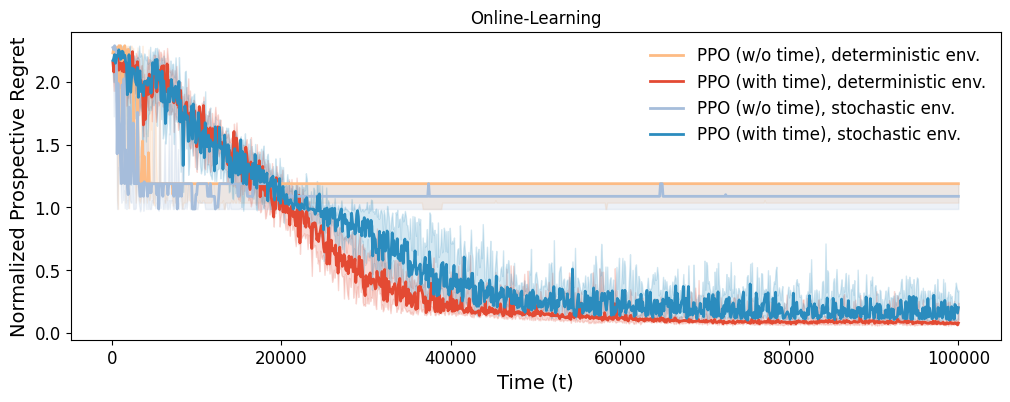

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
lw=2
fontsize = 14

color = "#fdbb84"
median, q1, q3 = get_median_and_iqr(results["det_notime"])
ax.plot(t_list, median, label='PPO (w/o time), deterministic env.', lw=lw, color=color)
ax.fill_between(t_list, q1, q3, alpha=0.2, color=color)

color = "#e34a33"
median, q1, q3 = get_median_and_iqr(results["det_time"])
ax.plot(t_list, median, label='PPO (with time), deterministic env.', lw=lw, color=color)
ax.fill_between(t_list, q1, q3, alpha=0.2, color=color)

color = "#a6bddb"
median, q1, q3 = get_median_and_iqr(results["sto_notime"])
ax.plot(t_list, median, label='PPO (w/o time), stochastic env.', lw=lw, color=color)
ax.fill_between(t_list, q1, q3, alpha=0.2, color=color)

color = "#2b8cbe"
median, q1, q3 = get_median_and_iqr(results["sto_time"])
ax.plot(t_list, median, label='PPO (with time), stochastic env.', lw=lw, color=color)
ax.fill_between(t_list, q1, q3, alpha=0.2, color=color)

ax.set_xlabel("Time (t)", fontsize=fontsize)
ax.set_ylabel("Normalized Prospective Regret", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize-2)
ax.legend(fontsize=fontsize-2, frameon=False)
ax.set_title("Online-Learning")
plt.show()

### Note on Deterministic vs. Stochastic Environment

In a stochastic environment, we introduce a noise parameter $\epsilon$ (epsilon), which represents the probability of an action "failing" or "slipping."

* **Success ($1 - \epsilon$):** The agent moves to the intended next state.
* **Failure ($\epsilon$):** The agent "slips" and remains in the current state $s$.

This transition logic is stored in a $7 \times 7$ matrix for each action. Each row in the matrix corresponds to the current state $s$, and each column corresponds to the potential next state $s'$.

**The Transition Matrix $T$ for "Move Right"**

$$
T_{right} = 
\begin{pmatrix}
\epsilon & 1-\epsilon & 0 & 0 & 0 & 0 & 0 \\
0 & \epsilon & 1-\epsilon & 0 & 0 & 0 & 0 \\
0 & 0 & \epsilon & 1-\epsilon & 0 & 0 & 0 \\
0 & 0 & 0 & \epsilon & 1-\epsilon & 0 & 0 \\
0 & 0 & 0 & 0 & \epsilon & 1-\epsilon & 0 \\
0 & 0 & 0 & 0 & 0 & \epsilon & 1-\epsilon \\
0 & 0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$

**The Transition Matrix $T$ for "Stay"**

$$
T_{stay} = 
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$

**The Transition Matrix $T$ for "Move Left"**

$$
T_{right} = 
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 \\
1-\epsilon & \epsilon & 0 & 0 & 0 & 0 & 0 \\
0 & 1-\epsilon & \epsilon & 0 & 0 & 0 & 0 \\
0 & 0 & 1-\epsilon & \epsilon & 0 & 0 & 0 \\
0 & 0 & 0 & 1-\epsilon & \epsilon & 0 & 0 \\
0 & 0 & 0 & 0 & 1-\epsilon & \epsilon & 0 \\
0 & 0 & 0 & 0 & 0 & 1-\epsilon & \epsilon
\end{pmatrix}
$$